In [153]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
from scipy.sparse.linalg import splu

### Q1

#### (a)

In [176]:
T = 100 # planning horizon
alpha, beta = 0.2, 1 # generator cost parameters
pmin, pmax = 0, 10 # generator limits
Q, C, D = 5, 1, 1 # battery parameters
# fixed load schedule
d = np.zeros(T) # Should not be (T, 1)
d[0:20] = 3
d[20:56] = 5
d[56:60] = 11
d[60:80] = 4
d[80:90] = 10
d[90:100] = 3

In [177]:
# mpgen, pbat = cp.Variable(T), cp.Variable(T)
# A = np.ones((T, T))
# A = np.concatenate([np.zeros((1, T)), np.tril(A)], axis=0)

# obj = cp.Minimize(alpha*cp.sum_squares(mpgen) + beta*cp.sum(mpgen))

# constraints = [d + pbat == mpgen, # consumed = produced
#                pmin <= mpgen, # >=pmin produced
#                mpgen <= pmax, # <=pmax produced
#                -D <= pbat, 
#                pbat <= C, 
#                0 <= A@pbat, 
#                A@pbat <= Q
#             ]

# problem = cp.Problem(obj, constraints)

# problem.solve()

In [178]:
mpgen, pload, pbat = cp.Variable(T), cp.Variable(T), cp.Variable(T)
A = np.ones((T, T))
A = np.concatenate([np.zeros((1, T)), np.tril(A)], axis=0)

# obj = cp.Minimize((mpgen.T)@(mpgen) + beta*(mpgen.T)@np.ones((T, 1)))
# obj = cp.Minimize(cp.sum(alpha*mpgen*mpgen + beta*mpgen))
obj = cp.Minimize(alpha*cp.sum_squares(mpgen) + beta*cp.sum(mpgen))
# obj = cp.Minimize(alpha*cp.sum_squares(mpgen) + beta*(mpgen.T)@np.ones(T)) # Working
# obj = cp.Minimize(alpha*mpgen.T@mpgen + beta*(mpgen.T)@np.ones(T)) # Not Working

constraints = [-mpgen + pload + pbat == 0,
               pmin <= mpgen, 
               mpgen <= pmax, 
               pload == d,
               -D <= pbat, 
               pbat <= C, 
               0 <= A@pbat, 
               A@pbat <= Q]

problem = cp.Problem(obj, constraints)

problem.solve()

np.float64(1065.005517994835)

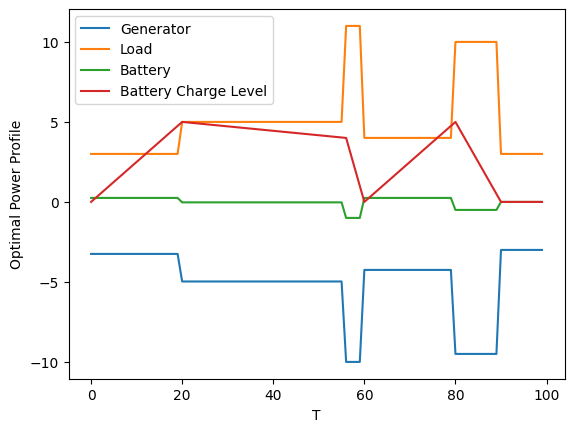

In [181]:
T_vec = [i for i in range(T)]
gen_val = -mpgen.value
load_val = pload.value
bat_val = pbat.value
plt.plot(T_vec, gen_val, label = "Generator")
plt.plot(T_vec, load_val, label = "Load")
plt.plot(T_vec, bat_val, label = "Battery")
plt.plot(T_vec, (A@bat_val)[:-1], label = "Battery Charge Level")
plt.xlabel("T")
plt.ylabel("Optimal Power Profile")
plt.legend()
plt.show()

#### (b)

In [229]:
def p1_solve(x1, xbar, u, k, lmda):
    mb = cp.Variable(T)
    objective = cp.Minimize(lmda*alpha*cp.sum_squares(mb) + lmda*beta*cp.sum(mb) + 1/2*cp.norm2(-mb - x1[k] + xbar[k] + u[k])**2)
    constraints = [pmax>=mb, mb>=pmin]
    problem = cp.Problem(objective, constraints)
    problem.solve()
    return -mb.value

def p3_solve(x3, xbar, u, k):
    b = cp.Variable(T)
    objective = cp.Minimize(1/2*cp.norm2(b - x3[k] + xbar[k] + u[k])**2)
    constraints = [-D<=b, b<=C, 0 <= A@b, A@b<=Q]
    problem = cp.Problem(objective, constraints)
    problem.solve()
    return b.value

num_iters = 100
sz = (num_iters, T)

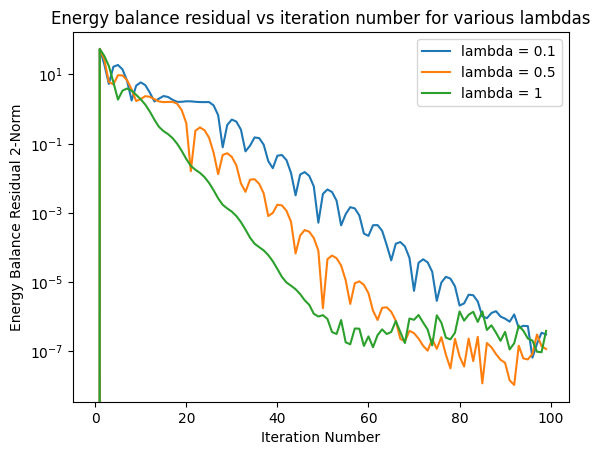

In [257]:
lmda_vec = [0.1, 0.5, 1] #? Not working for lambda >= 1
for lmda in lmda_vec:
    x1, x2, x3, xbar, u = np.zeros(sz), np.zeros(sz), np.zeros(sz), np.zeros(sz), np.zeros(sz)
    for k in range(num_iters-1):
        x1[k+1] = p1_solve(x1, xbar, u, k, lmda)
        x2[k+1] = d
        x3[k+1] = p3_solve(x3, xbar, u, k)
        xbar[k+1] = (x1[k+1] + x2[k+1] + x3[k+1])/3
        u[k+1] = u[k] + xbar[k+1]

    energy_balance_resid_norm = []
    for itr in range(num_iters):
        energy_balance_resid_norm.append(np.linalg.norm(3*xbar[itr])) #? Check again (the initial kink)
        # energy_balance_resid_norm.append(np.linalg.norm(A@x3[itr, :], 1))
    plt.plot(energy_balance_resid_norm, label = f"lambda = {lmda}")

plt.legend()
plt.xlabel("Iteration Number")
plt.ylabel("Energy Balance Residual 2-Norm")
plt.yscale("log")
plt.title(f"Energy balance residual vs iteration number for various lambdas")
plt.show()

In [254]:
# lambda = 1 here
x1, x2, x3, xbar, u = np.zeros(sz), np.zeros(sz), np.zeros(sz), np.zeros(sz), np.zeros(sz)
lmda = 1
for k in range(num_iters-1):
    x1[k+1] = p1_solve(x1, xbar, u, k, lmda)
    x2[k+1] = d
    x3[k+1] = p3_solve(x3, xbar, u, k)
    xbar[k+1] = (x1[k+1] + x2[k+1] + x3[k+1])/3
    u[k+1] = u[k] + xbar[k+1]

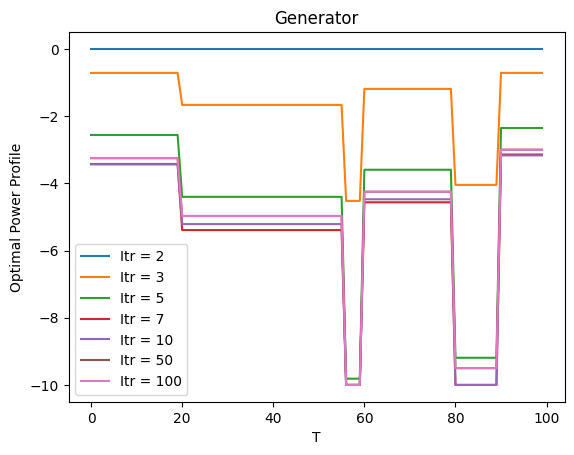

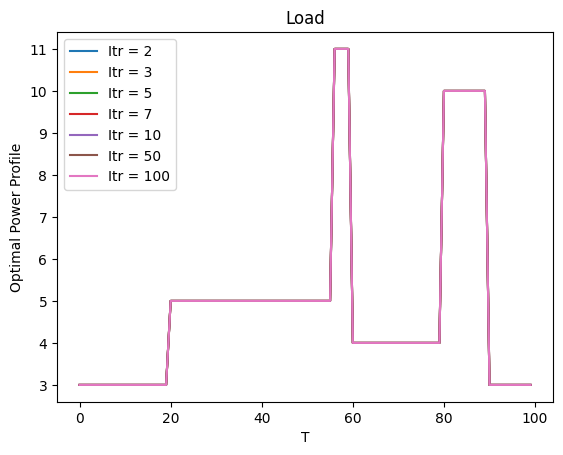

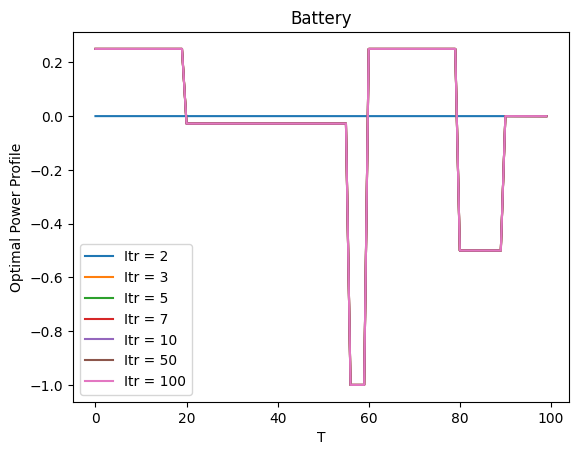

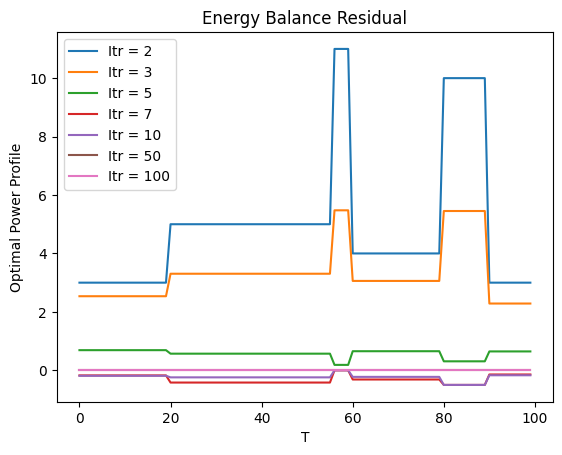

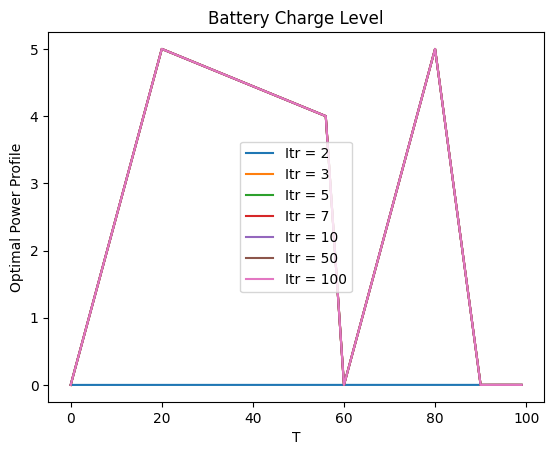

In [267]:
T_vec = [i for i in range(T)]
# labels = {x1: "Generator", x2: "Load", x3: "Battery", 3*xbar: "Energy Balance Residual", A@x3: "Battery Charge Level"}
itr_vec = [2, 3, 5, 7, 10, 50, 100]
vec_list = [x1, x2, x3, 3*xbar, A@(x3.T)]
label_list = ["Generator", "Load", "Battery", "Energy Balance Residual", "Battery Charge Level"]
for i in range(len(vec_list)):
    vec = vec_list[i]
    if(i!=4):
        for itr in itr_vec:
            plt.plot(T_vec, vec[itr-1], label = f"Itr = {itr}")
    else:
        for itr in itr_vec:
            plt.plot(T_vec, vec[:, itr-1][:-1], label = f"Itr = {itr}")
    plt.xlabel("T")
    plt.ylabel("Optimal Power Profile")
    plt.legend()
    plt.title(label_list[i])
    plt.show()

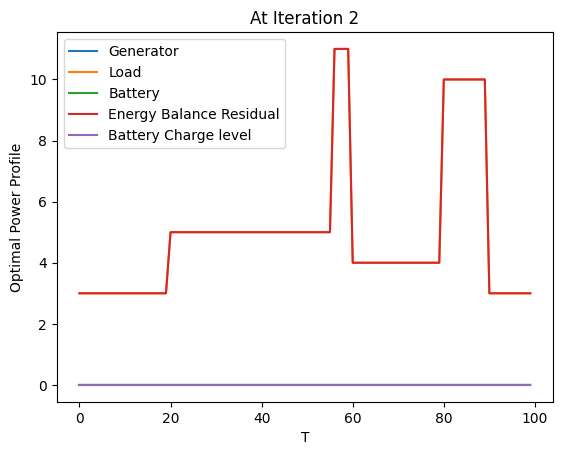

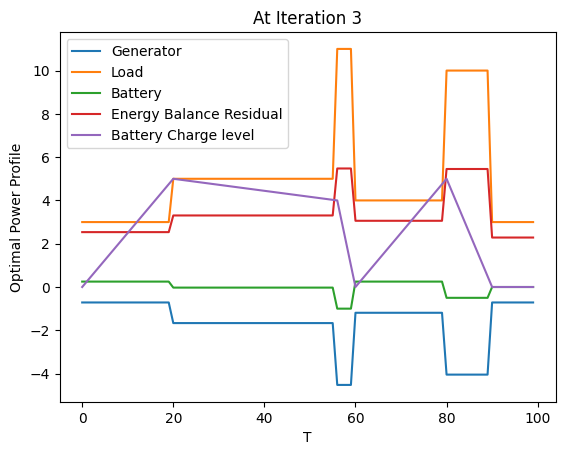

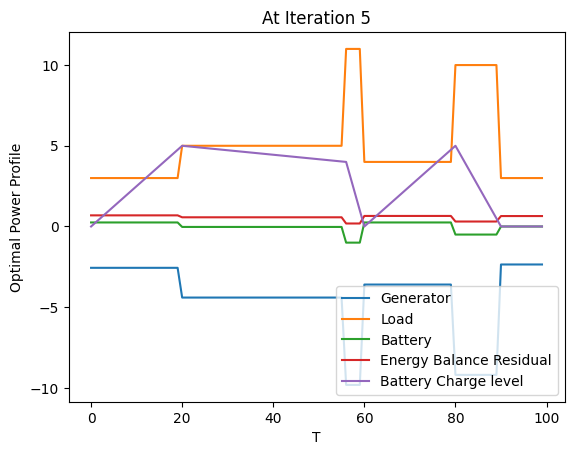

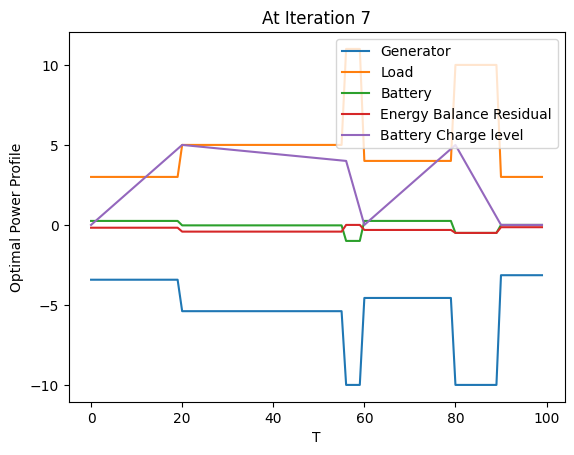

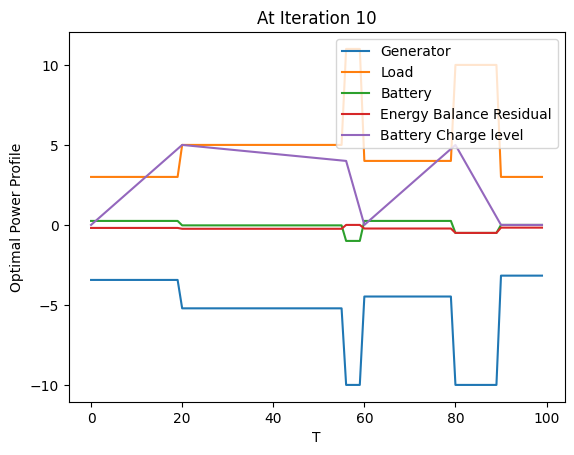

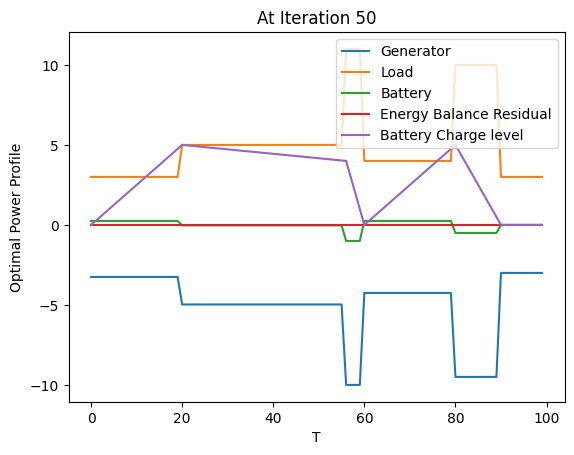

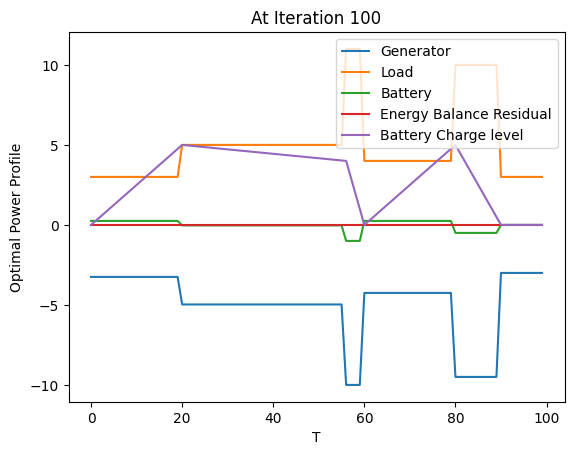

In [256]:
T_vec = [i for i in range(T)]
for itr in [2, 3, 5, 7, 10, 50, 100]:
    plt.plot(T_vec, x1[itr-1], label = "Generator")
    plt.plot(T_vec, x2[itr-1], label = "Load")
    plt.plot(T_vec, x3[itr-1], label = "Battery")
    plt.plot(T_vec, 3*xbar[itr-1], label = "Energy Balance Residual")
    plt.plot(T_vec, (A@x3[itr-1])[:-1], label = "Battery Charge level")
    plt.xlabel("T")
    plt.ylabel("Optimal Power Profile")
    plt.legend()
    plt.title(f"At Iteration {itr}")
    plt.show()

##### Results matching!

### Q2

#### (b)

In [168]:
def generate_randn_data(m,n):
    w = np.random.randn(n)
    x = np.maximum(w, 0)
    lambd = np.maximum(-w, 0)
    A = np.random.randn(m,n)
    nu = np.random.randn(m)
    b = A @ x
    
    c = lambd - A.T@nu
    return A, b, c, x, lambd, nu

# main body
m = 10
n = 20
A, b, c, x_solution, lambd_solution, nu_solution = generate_randn_data(m, n)

# splu_factorized = splu(A.T@A)
splu_factorized = splu(A@A.T)

/var/folders/h6/k0hvphys1p5b28sdmwwfkh9r0000gn/T/ipykernel_2925/575633807.py:18: SparseEfficiencyWarning: splu converted its input to CSC format
  splu_factorized = splu(A@A.T)


In [169]:
z = 0
x = 0
num_iters = 1000
resid_vec = []
for i in range(1, num_iters):
    z = np.maximum(z-x, x-c)
    # x = z + splu_factorized.solve(A.T@(b-A@z)) # Check for A.T here?
    x = z + A.T@splu_factorized.solve(b-A@z) # Check for A.T here?
    resid_vec.append(c.T@x)

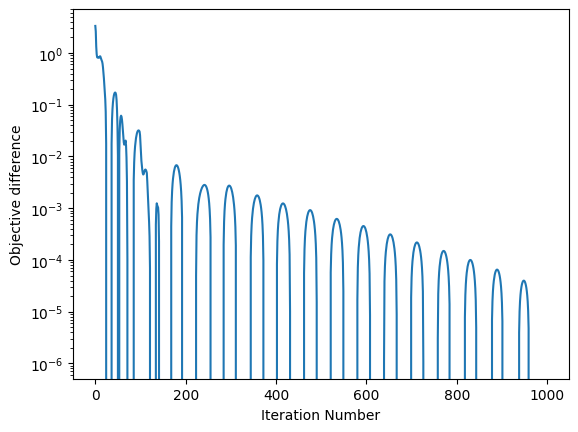

In [251]:
# Till now, resid_vec is c.T@xk
resid_vec = np.array(resid_vec)
# c.T@xk - c.T@x* (last element)
resid_vec -= resid_vec[-1]
# resid_vec -= c.T@x_solution
plt.plot(resid_vec)
plt.xlabel("Iteration Number")
plt.ylabel("Objective difference")
plt.yscale("log")
plt.show()

##### Showing that x is feasible:
- x>=0 (upto numerical inaccuracies)
- A@x = b => A@x-b = 0 

In [171]:
x

array([ 1.01437755e-05,  5.35510528e-06, -1.73352732e-05,  2.34148499e+00,
       -5.37735256e-06,  7.62459542e-01,  2.17976116e-05,  1.62425181e-05,
        6.62922722e-01,  2.15180036e+00,  1.13880672e-05,  4.09684162e-05,
        7.87172950e-01,  2.65659228e-06,  1.30939876e-06,  1.99204067e-01,
        5.46717796e-01, -2.58131242e-05,  2.63095999e-01,  1.68921136e+00])

In [172]:
A@x-b

array([-1.33226763e-15, -7.21644966e-15,  1.55431223e-15,  8.88178420e-15,
        2.66453526e-15,  0.00000000e+00,  9.10382880e-15,  3.10862447e-15,
        0.00000000e+00,  6.21724894e-15])

#### (c)

##### It is the same one mentioned in part (a) of this question: "for i=1:99;z=max(z-x,x-c);x=z+A\(b-A*z);end" => 43 characters (Julia code).

### Q3

#### (d)

##### CVXPY

In [54]:
L = 1
u_vec = [0.1*i for i in range(1, 10)]
gamma_vec = []
output_vec = []
for u in u_vec:
    G = cp.Variable((3, 3))
    F = cp.Variable()
    gamma = 2/(u+L)
    gamma_vec.append(gamma)
    
    objective = cp.Maximize(G[1, 1] + gamma**2*G[2, 2] - 2*gamma*G[1, 2])

    constraints = [F + (L*u)/(2*(L-u))*G[1, 1] + 1/(2*(L-u))*G[2, 2] - L/(L-u)*G[1, 2] <= 0, 
                -F + (L*u)/(2*(L-u))*G[1, 1] + 1/(2*(L-u))*G[2, 2] - u/(L-u)*G[1, 2] <= 0,
                G[1, 1] <= 1,
                G[:, 0] == 0,
                G[0, :] == 0, 
                cp.PSD(G)]

    problem = cp.Problem(objective, constraints)

    problem.solve()
    # print(problem.value)
    output_vec.append(problem.value)

##### PEP

In [75]:
from PEPit import PEP
from PEPit.functions import SmoothStronglyConvexFunction

In [238]:
output_vec_pep = []
for u in u_vec:
    gamma = 2/(L+u)
    problem = PEP()
    func = problem.declare_function(SmoothStronglyConvexFunction, mu = u, L = 1)
    x0 = problem.set_initial_point()
    x1 = x0 - gamma * func.gradient(x0)
    f1 = func(x1)
    xs = func.stationary_point()
    fs = func(xs)
    
    problem.set_initial_condition((x0 - xs)**2 <= 1)
    # problem.set_performance_metric(f1 - fs)
    problem.set_performance_metric((x1 - xs)**2) # Since the beta bound is on this quantity, NOT on the difference between the f values

    pepit_tau = problem.solve(verbose = False)
    output_vec_pep.append(pepit_tau)

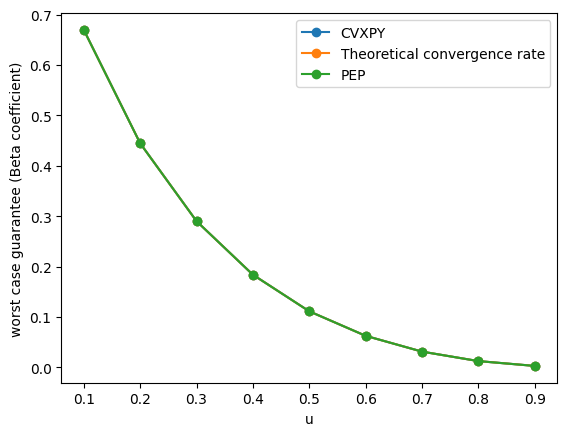

In [244]:
plt.plot(u_vec, output_vec, "-o", label="CVXPY")
plt.plot(u_vec, [((L-u)/(L+u))**2 for u in u_vec], "-o", label = "Theoretical convergence rate")
plt.plot(u_vec, output_vec_pep, "-o", label="PEP")
plt.legend()
plt.xlabel("u")
plt.ylabel("worst case guarantee (Beta coefficient)")
plt.show()

##### Theoretical convergence rates match exactly with those obtained from CVXPY and PEP (which also match each other), indicating that the engines are efficient!